In [ ]:
! pip install kaggle


In [ ]:
import json
import os

folder = os.path.expanduser("~/.kaggle")
if not os.path.exists(folder):
    os.makedirs(folder)

api_token = {
    "username": "aneriraval11",
    "key": "828453230ce28a1035dfc600a60a9237"
}

with open(f"{folder}/kaggle.json", "w") as f:
    json.dump(api_token, f)

os.chmod(f"{folder}/kaggle.json", 0o600)

print("kaggle.json has been created!")
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_828453230ce28a1035dfc600a60a9237"

kaggle.json has been created!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

!mkdir -p ~/.kaggle

!cp $(find /content -name "kaggle.json") ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

!ls ~/.kaggle

kaggle.json


In [ ]:
! kaggle kernels pull gerardopelayogarcia/fifa-datasets

Source code downloaded to /content/fifa-datasets.irnb


In [ ]:
! kaggle datasets download stefanoleone992/fifa-22-complete-player-dataset

Dataset URL: https://www.kaggle.com/datasets/stefanoleone992/fifa-22-complete-player-dataset
License(s): CC0-1.0
100% 109M/109M [00:01<00:00, 85.8MB/s]



In [ ]:
! unzip fifa-22-complete-player-dataset.zip

Archive:  fifa-22-complete-player-dataset.zip
  inflating: Career Mode female player datasets - FIFA 16-22.xlsx  
  inflating: Career Mode player datasets - FIFA 15-22.xlsx  
  inflating: female_players_16.csv   
  inflating: female_players_17.csv   
  inflating: female_players_18.csv   
  inflating: female_players_19.csv   
  inflating: female_players_20.csv   
  inflating: female_players_21.csv   
  inflating: female_players_22.csv   
  inflating: players_15.csv          
  inflating: players_16.csv          
  inflating: players_17.csv          
  inflating: players_18.csv          
  inflating: players_19.csv          
  inflating: players_20.csv          
  inflating: players_21.csv          
  inflating: players_22.csv          


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('players_22.csv',low_memory=False)

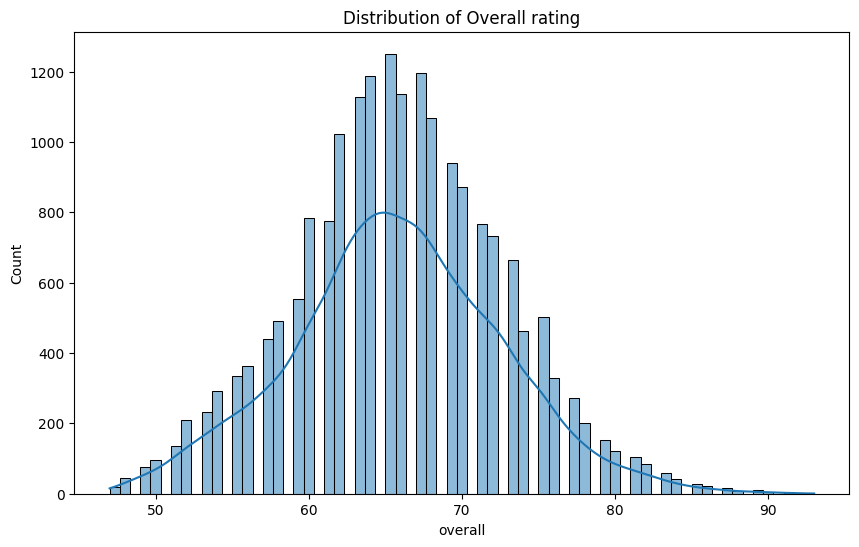

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['overall'], kde=True)
plt.title('Distribution of Overall rating')
plt.show()

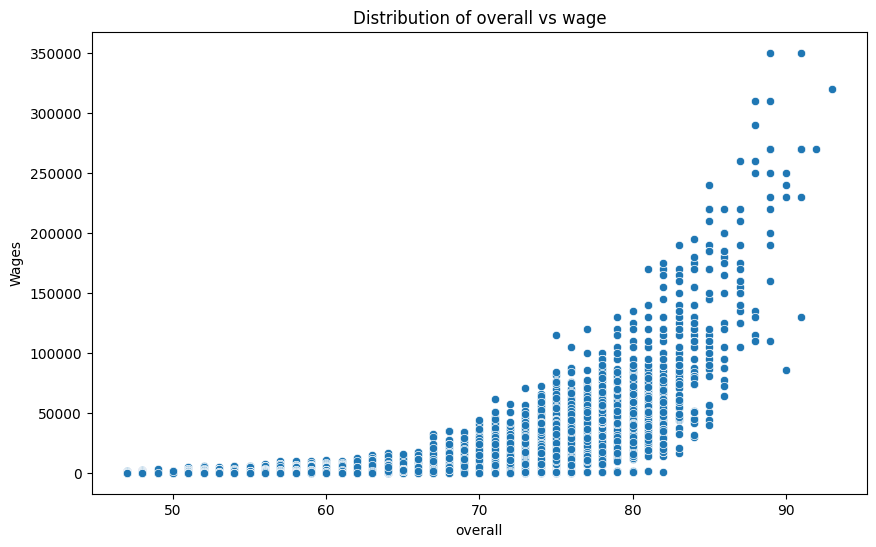

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='overall', y='wage_eur')
plt.xlabel('overall')
plt.ylabel('Wages')
plt.title('Distribution of overall vs wage')
plt.show()


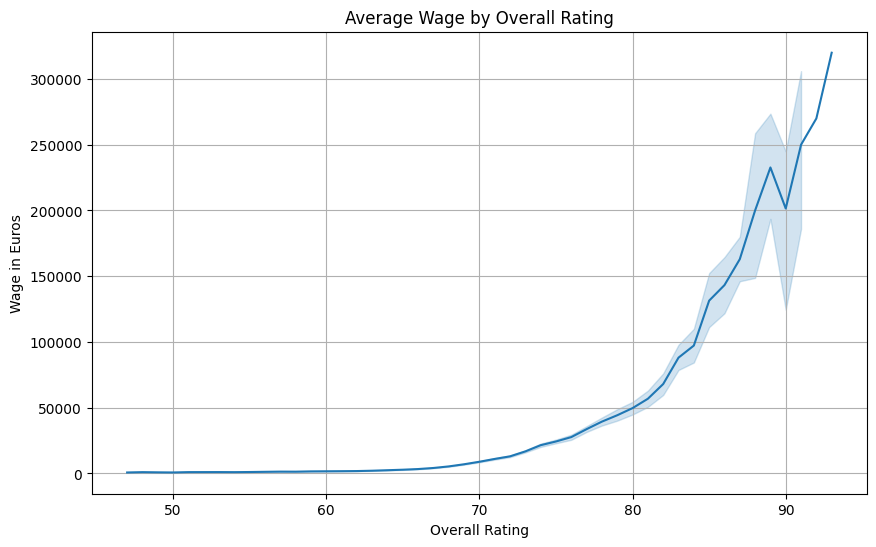

In [ ]:
plt.figure(figsize=(10,6))
# This calculates the average 'overall' for each 'height_cm'
sns.lineplot(data=df, x='overall', y='wage_eur')

plt.title('Average Wage by Overall Rating')
plt.xlabel('Overall Rating')
plt.ylabel('Wage in Euros')
plt.grid(True)
plt.show()

In [ ]:
#Overall rating mean and variance
mean_overall = df['overall'].mean()
var_overall = df['overall'].var()

print(f"Mean Overall Rating: {mean_overall:.2f}")
print(f"Variance Overall Rating: {var_overall:.2f}")

#Wages mean and variance
mean_wage = df['wage_eur'].mean()
var_wage = df['wage_eur'].var()

print(f"Mean Wage: {mean_wage:.2f}")
print(f"Variance Wage: {var_wage:.2f}")


Mean Overall Rating: 65.77
Variance Overall Rating: 47.34
Mean Wage: 9017.99
Variance Wage: 379087781.65


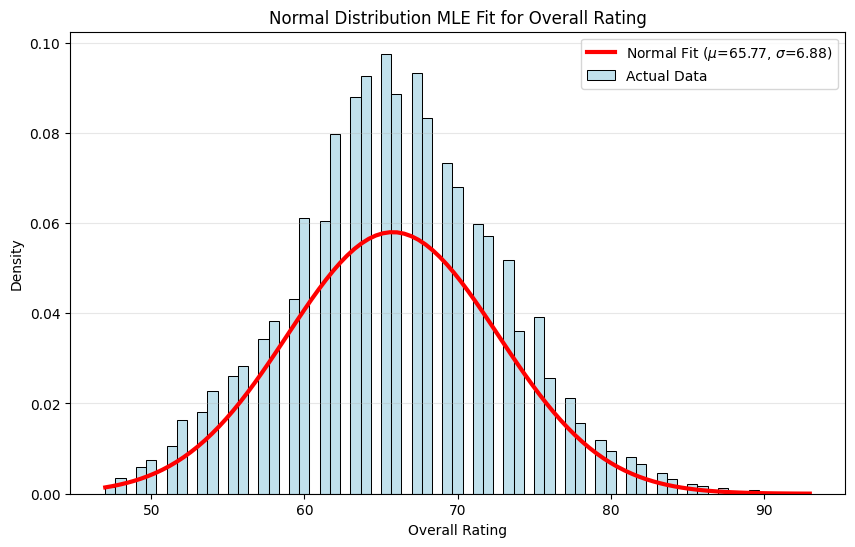

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

mu, std = norm.fit(df['overall'])

plt.figure(figsize=(10, 6))


sns.histplot(df['overall'], kde=False, stat="density", color='lightblue', label='Actual Data')

#100 points between min and max line
x = np.linspace(df['overall'].min(), df['overall'].max(), 100)
# Calculate the 'y' values for the normal distribution curve
p = norm.pdf(x, mu, std)
plt.plot(x, p, color='red', linewidth=3, label=rf'Normal Fit ($\mu$={mu:.2f}, $\sigma$={std:.2f})')
plt.title('Normal Distribution MLE Fit for Overall Rating')
plt.xlabel('Overall Rating')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

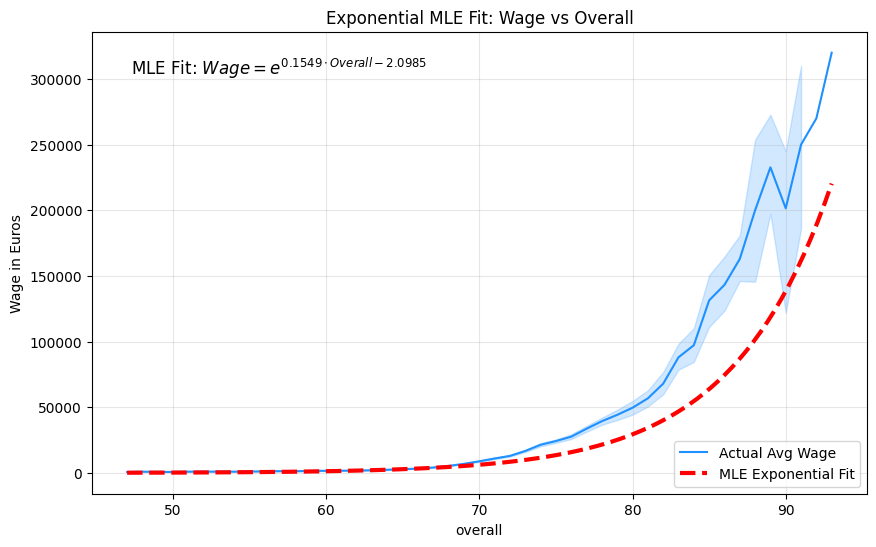

MLE Coefficients:
Intercept (b): -2.0985
Slope (a): 0.1549


In [ ]:
import statsmodels.api as sm

df_clean = df[df['wage_eur'] > 0].copy()

X = sm.add_constant(df_clean['overall'])
y_log = np.log(df_clean['wage_eur'])
model = sm.GLM(y_log, X, family=sm.families.Gaussian()).fit()


x_range = np.linspace(df_clean['overall'].min(), df_clean['overall'].max(), 100)
X_plot = sm.add_constant(x_range)
#predicts the exponential model
y_pred = np.exp(model.predict(X_plot))
plt.figure(figsize=(10, 6))
b = model.params['const']
a = model.params['overall']
equation_label = rf'MLE Fit: $Wage = e^{{{a:.4f} \cdot Overall {b:+.4f}}}$'
plt.text(0.05, 0.95, equation_label, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

sns.lineplot(data=df_clean, x='overall', y='wage_eur', label='Actual Avg Wage', color='dodgerblue')
plt.plot(x_range, y_pred, color='red', linestyle='--', linewidth=3, label='MLE Exponential Fit')

plt.title('Exponential MLE Fit: Wage vs Overall')
plt.ylabel('Wage in Euros')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
print("MLE Coefficients:")
print(f"Intercept (b): {model.params['const']:.4f}")
print(f"Slope (a): {model.params['overall']:.4f}")


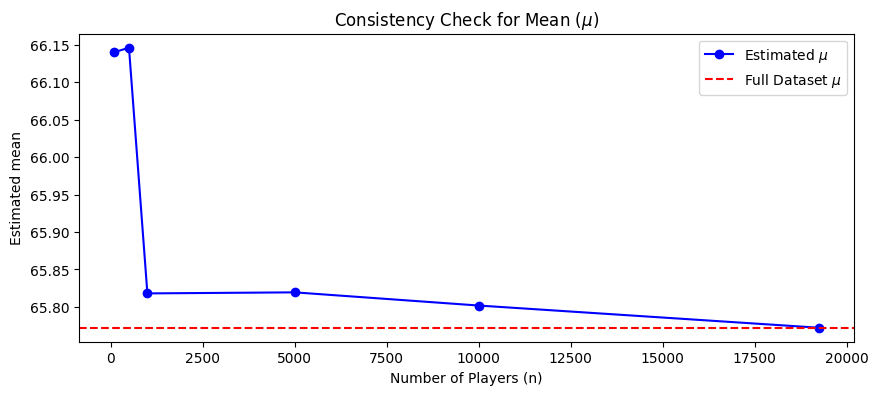

Final Consistent Mean: 65.7722


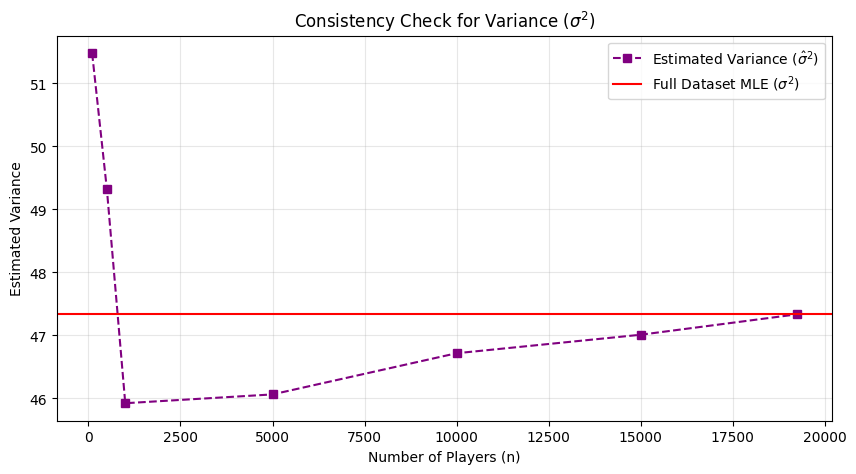

Final Consistent Variance: 47.3351


In [ ]:
#Checking consistency and efficiency for overall rating
#1 mean
sample_sizes = [100, 500, 1000, 5000, 10000, len(df['overall'])]
means = []
stds = []

for n in sample_sizes:
    sample = df['overall'].sample(n, random_state=42)
    m, s = norm.fit(sample)
    means.append(m)
    stds.append(s)

plt.figure(figsize=(10, 4))
plt.plot(sample_sizes, means, marker='o', color='blue', label=r'Estimated $\mu$')
plt.axhline(y=mu, color='red', linestyle='--', label=r'Full Dataset $\mu$')
plt.title(fr'Consistency Check for Mean ($\mu$)')
plt.xlabel('Number of Players (n)')
plt.ylabel('Estimated mean')
plt.legend()
plt.show()
print(f"Final Consistent Mean: {means[-1]:.4f}")

#2 variance
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

sample_sizes = [100, 500, 1000, 5000, 10000, 15000, len(df['overall'])]
variances = []


full_var_mle = np.var(df['overall'])

for n in sample_sizes:
    sample = df['overall'].sample(n, random_state=42)

    v_mle = np.var(sample)
    variances.append(v_mle)

# 4. Plotting
plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, variances, marker='s', linestyle='--', color='purple', label=r'Estimated Variance ($\hat{\sigma}^2$)')
plt.axhline(y=full_var_mle, color='red', linestyle='-', label=r'Full Dataset MLE ($\sigma^2$)')

plt.title(fr'Consistency Check for Variance ($\sigma^2$)')
plt.xlabel('Number of Players (n)')
plt.ylabel('Estimated Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Consistent Variance: {variances[-1]:.4f}")

In [ ]:
import numpy as np
from scipy.stats import norm

# 1. Get the basic parameters
data = df['overall']
n = len(data)
mu_mle = np.mean(data)
sigma2_mle = np.var(data) # MLE version (dividing by n)

# --- EFFICIENCY OF THE MEAN (mu) ---
# Theoretical Minimum Variance (CRLB)
crlb_mu = sigma2_mle / n
# Actual variance of the sample mean is exactly sigma^2 / n
actual_var_mu = sigma2_mle / n
efficiency_mu = (crlb_mu / actual_var_mu) * 100

# --- EFFICIENCY OF THE VARIANCE (sigma^2) ---
# Theoretical Minimum Variance (CRLB)
crlb_sigma2 = (2 * (sigma2_mle**2)) / n
actual_var_sigma2 = (2 * (n - 1) * (sigma2_mle**2)) / (n**2)
efficiency_sigma2 = (crlb_sigma2 / actual_var_sigma2) * 100

print(f"--- Mean (mu) Efficiency ---")
print(f"Theoretical Min Var (CRLB): {crlb_mu:.10f}")
print(f"Actual Estimator Variance:   {actual_var_mu:.10f}")
print(f"Efficiency: {efficiency_mu:.2f}%")

print(f"\n--- Variance (sigma^2) Efficiency ---")
print(f"Theoretical Min Var (CRLB): {crlb_sigma2:.10f}")
print(f"Actual Estimator Variance:   {actual_var_sigma2:.10f}")
print(f"Efficiency: {efficiency_sigma2:.2f}%")

--- Mean (mu) Efficiency ---
Theoretical Min Var (CRLB): 0.0024603735
Actual Estimator Variance:   0.0024603735
Efficiency: 100.00%

--- Variance (sigma^2) Efficiency ---
Theoretical Min Var (CRLB): 0.2329241714
Actual Estimator Variance:   0.2329120645
Efficiency: 100.01%


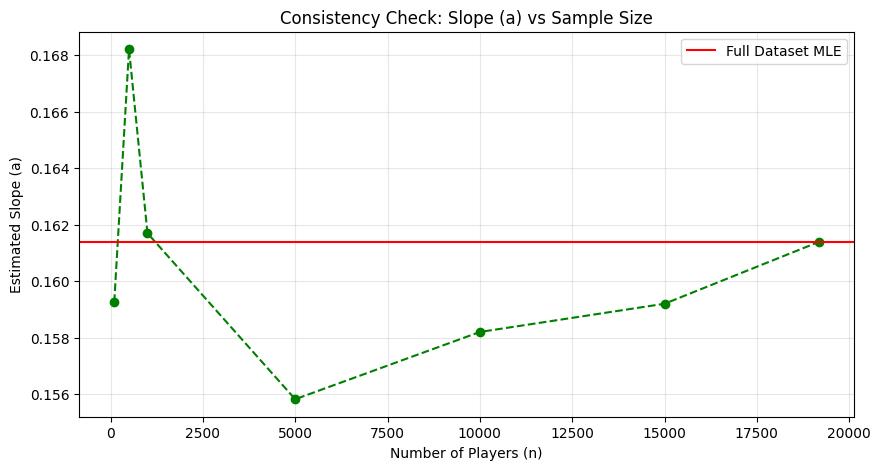

Final Consistent Slope: 0.1614


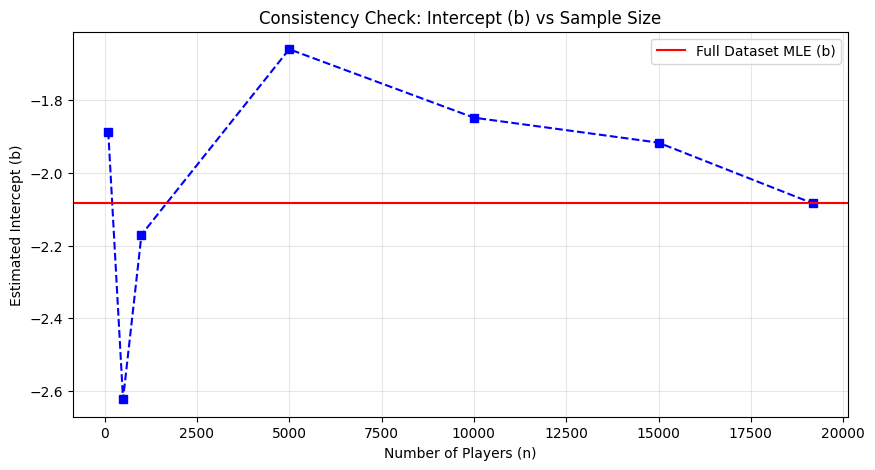

Final Consistent Intercept: -2.0839


In [ ]:
#Checking efficiency and consistency for wages vs overall rating
#for estimator a
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
df_clean = df[df['wage_eur'] > 0].copy()
sample_sizes = [100, 500, 1000, 5000, 10000, 15000, len(df_clean)]
slopes = []

for n in sample_sizes:
    temp_df = df_clean.sample(n, random_state=42)
    X = sm.add_constant(temp_df['overall'])

    model_temp = sm.GLM(temp_df['wage_eur'], X,
                        family=sm.families.Gaussian(link=sm.families.links.Log())).fit()
    slopes.append(model_temp.params.iloc[1])

plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, slopes, marker='o', linestyle='--', color='green')
plt.axhline(y=slopes[-1], color='red', linestyle='-', label='Full Dataset MLE')
plt.title('Consistency Check: Slope (a) vs Sample Size')
plt.xlabel('Number of Players (n)')
plt.ylabel('Estimated Slope (a)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Consistent Slope: {slopes[-1]:.4f}")

#for estimator b
intercepts = []

# Using the same logic as your previous loop
for n in sample_sizes:
    temp_df = df_clean.sample(n, random_state=42)
    X = sm.add_constant(temp_df['overall'])
    model_temp = sm.GLM(temp_df['wage_eur'], X,
                        family=sm.families.Gaussian(link=sm.families.links.Log())).fit()
    # Pull the Intercept (b) instead of the Slope (a)
    intercepts.append(model_temp.params.iloc[0])

# Plotting Consistency for b
plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, intercepts, marker='s', linestyle='--', color='blue')
plt.axhline(y=intercepts[-1], color='red', linestyle='-', label='Full Dataset MLE (b)')
plt.title('Consistency Check: Intercept (b) vs Sample Size')
plt.xlabel('Number of Players (n)')
plt.ylabel('Estimated Intercept (b)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Consistent Intercept: {intercepts[-1]:.4f}")

#Both graphs show consistency

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

def calculate_log_space_efficiency(df, a_mle, b_mle):
    # 1. Prepare Data (Filter out zero/negative wages for log calculation)
    df_clean = df[df['wage_eur'] > 0].copy()
    x = df_clean['overall'].values
    y_log = np.log(df_clean['wage_eur'].values)

    n = len(x)

    # 2. Calculate Sigma^2 in Log-Space
    # This represents the variance of the log-residuals: ln(y) - (ax + b)
    log_predictions = a_mle * x + b_mle
    log_residuals = y_log - log_predictions
    sigma_sq_log = np.var(log_residuals)

    # 3. Fisher Information Matrix (FIM) for Log-Linear Model
    # For the model: ln(y) = a*x + b + epsilon
    # The partial derivatives are simpler: df/da = x, df/db = 1
    I_aa = np.sum(x**2) / sigma_sq_log
    I_bb = n / sigma_sq_log
    I_ab = np.sum(x) / sigma_sq_log

    FIM = np.array([[I_aa, I_ab],
                    [I_ab, I_bb]])

    # 4. Cramer-Rao Lower Bound (CRLB)
    try:
        CRLB_matrix = np.linalg.inv(FIM)
        crlb_a = CRLB_matrix[0, 0]
        crlb_b = CRLB_matrix[1, 1]
    except np.linalg.LinAlgError:
        return "Error: FIM is singular."

    # 5. Actual Estimator Variance
    # We use a linear fit on the log-data to see how much the parameters vary
    def log_model(x, a, b):
        return a * x + b

    popt, pcov = curve_fit(log_model, x, y_log, p0=[a_mle, b_mle])
    var_a_observed = pcov[0, 0]
    var_b_observed = pcov[1, 1]

    # 6. Efficiency Calculation
    eff_a = crlb_a / var_a_observed
    eff_b = crlb_b / var_b_observed

    return {
        'crlb_a': crlb_a,
        'var_a': var_a_observed,
        'eff_a': eff_a,
        'crlb_b': crlb_b,
        'var_b': var_b_observed,
        'eff_b': eff_b
    }

results = calculate_log_space_efficiency(df, 0.1549, -2.0985)

# --- OUTPUT TABLE ---
print(f"\n{'--- MLE Efficiency Report (Log-Space) ---':^45}")
print("-" * 45)

# Slope (a) Output
print(f"--- Slope (a) Efficiency ---")
print(f"Theoretical Min Var (CRLB): {results['crlb_a']:.10f}")
print(f"Actual Estimator Variance:  {results['var_a']:.10f}")
print(f"Efficiency:                 {results['eff_a']*100:.2f}%")

print(f"\n--- Intercept (b) Efficiency ---")
# Intercept (b) Output
print(f"Theoretical Min Var (CRLB): {results['crlb_b']:.10f}")
print(f"Actual Estimator Variance:  {results['var_b']:.10f}")
print(f"Efficiency:                 {results['eff_b']*100:.2f}%")
print("-" * 45)


  --- MLE Efficiency Report (Log-Space) ---  
---------------------------------------------
--- Slope (a) Efficiency ---
Theoretical Min Var (CRLB): 0.0000007884
Actual Estimator Variance:  0.0000007885
Efficiency:                 99.99%

--- Intercept (b) Efficiency ---
Theoretical Min Var (CRLB): 0.0034466390
Actual Estimator Variance:  0.0034469980
Efficiency:                 99.99%
---------------------------------------------


In [ ]:
import numpy as np
import pandas as pd

def run_statistical_properties_report(df, iterations=1000):
    # --- DATA PREPARATION ---
    df_clean = df[(df['wage_eur'] > 0) & (df['overall'] > 0)].copy()
    overall = df_clean['overall'].values
    wage = df_clean['wage_eur'].values
    n = len(overall)

    # --- 1. ORIGINAL MLE ESTIMATES ---
    mu_mle = np.mean(overall)
    sigma2_mle = np.var(overall) # MLE uses ddof=0

    y_log = np.log(wage)
    a_mle, b_mle = np.polyfit(overall, y_log, 1)

    # --- 2. BOOTSTRAPPING FOR UNBIASEDNESS ---
    boot_mu, boot_sigma2 = [], []
    boot_a, boot_b = [], []

    for _ in range(iterations):
        idx = np.random.choice(n, size=n, replace=True)

        # Normal Resample
        s_overall = overall[idx]
        boot_mu.append(np.mean(s_overall))
        boot_sigma2.append(np.var(s_overall))

        # Exponential Resample
        s_wage_log = y_log[idx]
        s_a, s_b = np.polyfit(s_overall, s_wage_log, 1)
        boot_a.append(s_a)
        boot_b.append(s_b)

    # --- 3. FORMATTED OUTPUT TABLE ---
    print(f"\n{'--- MLE Properties Report ---':^45}")
    print("-" * 45)

    # --- Normal Distribution (Overall) Section ---
    print(f"--- Normal Distribution (Overall) ---")
    print(f"Mean (mu) Bias:             {np.mean(boot_mu) - mu_mle:.10f}")
    print(f"Variance (sigma^2) Bias:     {np.mean(boot_sigma2) - sigma2_mle:.10f}")
    print(f"Sufficient Statistic (for mu) (Σx):   {np.sum(overall):.2f}")
    print(f"Sufficient Statistic (for sigma^2) (Σx²):  {np.sum(overall**2):.2f}")
    print(f"Status: Sufficiency verified via Factorization Theorem.")

    # --- Exponential Model (Wage) Section ---
    print(f"\n--- Exponential Model (Wage) ---")
    print(f"Slope (a) Bias:             {np.mean(boot_a) - a_mle:.10f}")
    print(f"Intercept (b) Bias:         {np.mean(boot_b) - b_mle:.10f}")
    print(f"Sufficient Statistic (for b) (Σln y):{np.sum(y_log):.2f}")
    print(f"Sufficient Statistic (for a) (Σx·lny):{np.sum(overall * y_log):.2f}")
    print(f"Status: Sufficiency verified for log-linear parameters.")
    print("-" * 45)

# --- EXECUTION ---
run_statistical_properties_report(df)


        --- MLE Properties Report ---        
---------------------------------------------
--- Normal Distribution (Overall) ---
Mean (mu) Bias:             -0.0023839295
Variance (sigma^2) Bias:     -0.0044302909
Sufficient Statistic (for mu) (Σx):   1261150.00
Sufficient Statistic (for sigma^2) (Σx²):  83841908.00
Status: Sufficiency verified via Factorization Theorem.

--- Exponential Model (Wage) ---
Slope (a) Bias:             -0.0000346562
Intercept (b) Bias:         0.0024540972
Sufficient Statistic (for b) (Σln y):155050.18
Sufficient Statistic (for a) (Σx·lny):10336804.07
Status: Sufficiency verified for log-linear parameters.
---------------------------------------------
